In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/home/lena/Promotion/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 1.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 0.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0, data_1, data_2 = dict(), dict(), dict()
data_0["coordinates"] = coords[0]
data_1["coordinates"] = coords[0]
data_2["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0, data_1, data_2]:
    d["weights"] = np.array([-7.5, -15., -30.])
    d["control"] = [None] * len(data_0["weights"])
    d["state"] = [None] * len(data_0["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb.pickle'), 'wb') as f:
        pickle.dump([data_0, data_1, data_2], f)

controlmat = np.ones((N))
costmat = np.ones((N))

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


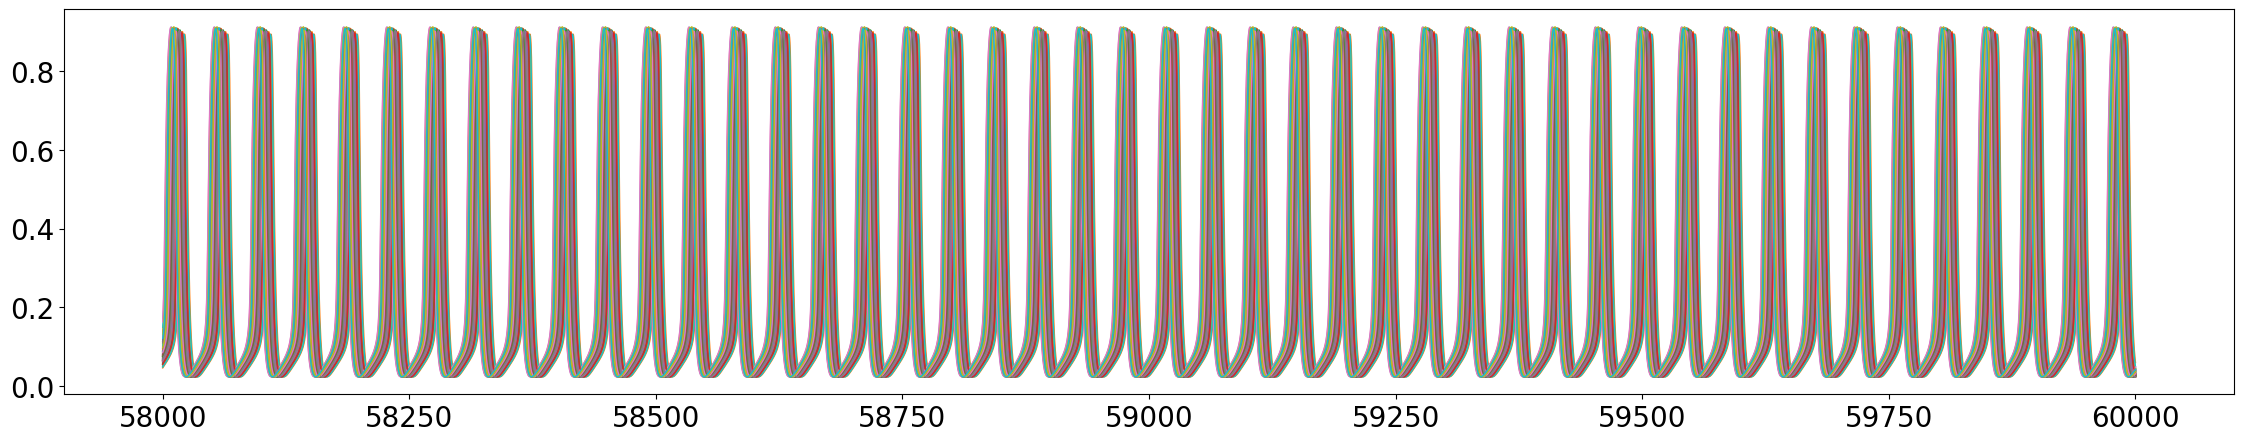

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1mFailed in nopython mode pipeline (step: nopython frontend)
[1m[1mNo implementation of function Function(<built-in function iadd>) found for signature:
 
 >>> iadd(float64, array(float64, 1d, C))
 
There are 18 candidate implementations:
[1m  - Of which 16 did not match due to:
  Overload of function 'iadd': File: <numerous>: Line N/A.
    With argument(s): '(float64, array(float64, 1d, C))':[0m
[1m   No match.[0m
[1m  - Of which 2 did not match due to:
  Operator Overload in function 'iadd': File: unknown: Line unknown.
    With argument(s): '(float64, array(float64, 1d, C))':[0m
[1m   No match for registered cases:
    * (int64, int64) -> int64
    * (int64, uint64) -> int64
    * (uint64, int64) -> int64
    * (uint64, uint64) -> uint64
    * (float32, float32) -> float32
    * (float64, float64) -> float64
    * (complex64, complex64) -> complex64
    * (complex128, complex128) -> comple

In [ ]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0["coordinates"][0]
    model.params.exc_inh_baseline = data_0["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0["init_state"] = [einit, iinit]
        data_0["state_uncontrolled"] = state.copy()
    else:
        data_1["init_state"] = [einit, iinit]
        data_1["state_uncontrolled"] = state.copy()

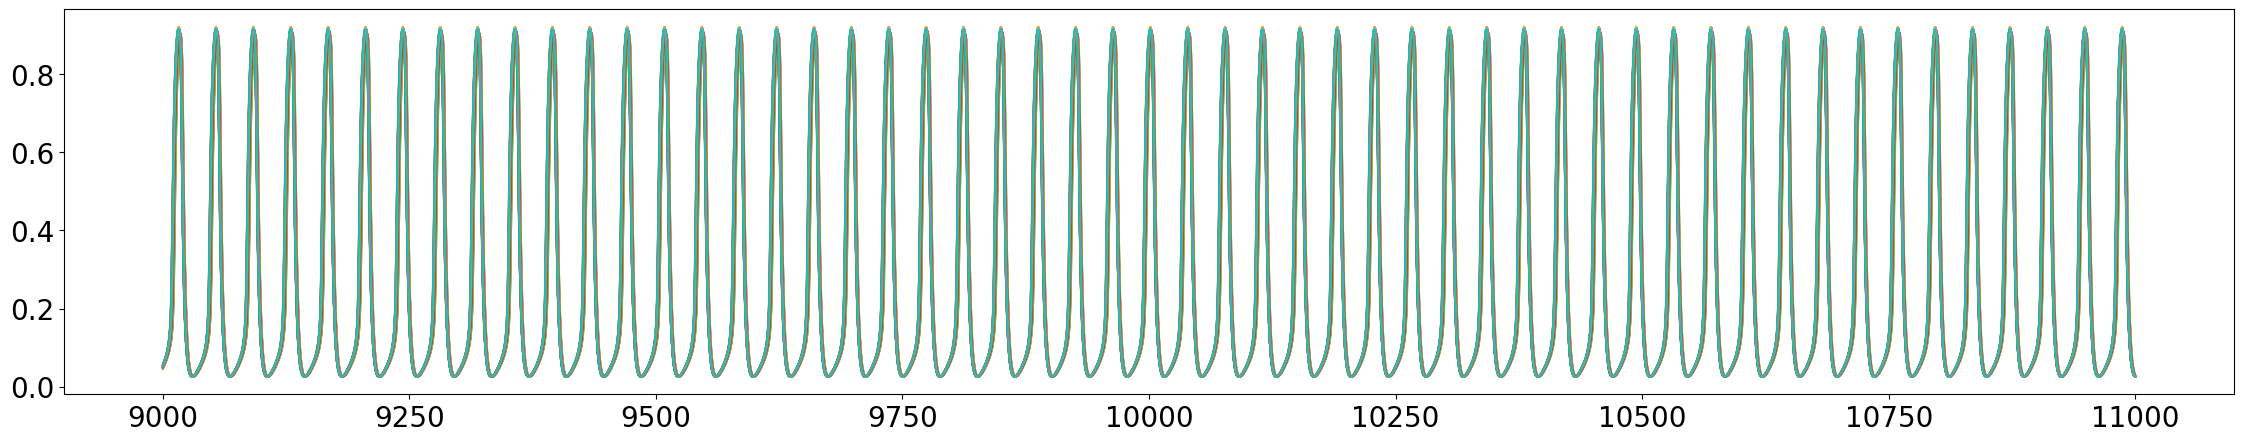

0.002332105821483664
-0.9775374609292389


In [7]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2["coordinates"][0]
model.params.exc_inh_baseline = data_2["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2["init_state"] = [einit, iinit]
data_2["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [7]:
with open(os.path.join(datadir, 'wb.pickle'), 'rb') as f:
    data_read = pickle.load(f)

[data_0, data_1, data_2] = data_read

In [9]:
data_1["weights"] = np.array([20., 30., 40.])

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 1.2708738458443412
Cost in iteration 1: 1.2672224256317781
Final cost : 1.2672224256317781
Compute control for a deterministic system
Cost in iteration 0: 1.2672224256317781
Cost in iteration 1: 1.2668107014446641
Cost in iteration 2: 1.2660330237557784
Cost in iteration 3: 1.2646478550974745
Cost in iteration 4: 1.2624632872619546
Final cost : 1.2624632872619546
Compute control for a deterministic system
Cost in iteration 0: 1.2624632872619546
Cost in iteration 1: 1.2580944227632607
Cost in iteration 2: 1.257141154011991
Cost in iteration 3: 1.2561848588124935
Cost in iteration 4: 1.2546334300069155
Final cost : 1.2546334300069155


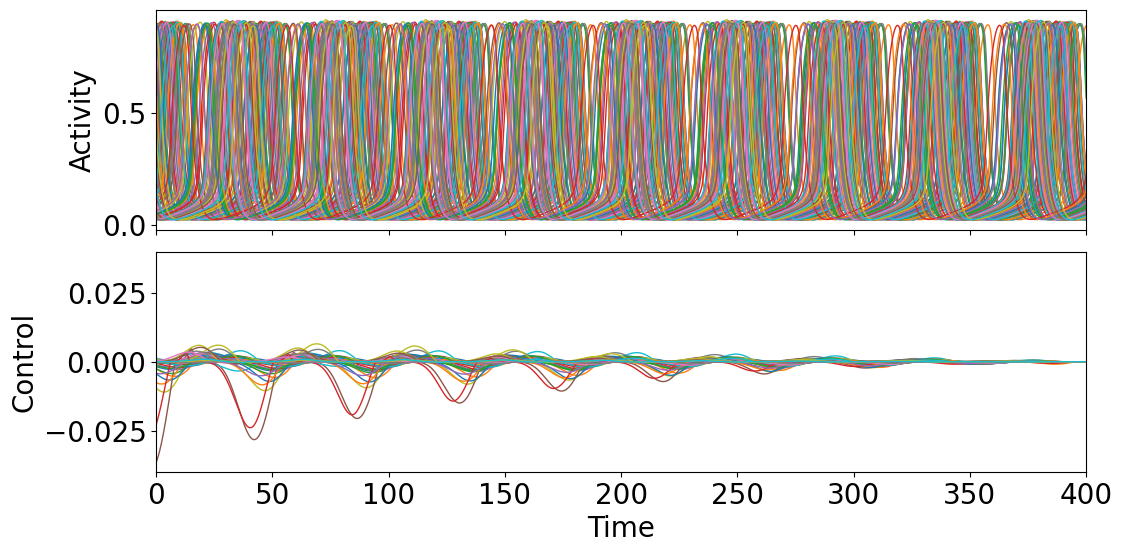

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 2.5417476916886823
Cost in iteration 1: 2.5136677398758067
Final cost : 2.5136677398758067
Compute control for a deterministic system
Cost in iteration 0: 2.5136677398758067
Cost in iteration 1: 2.510393308744572
Cost in iteration 2: 2.5040081878922735
Cost in iteration 3: 2.491784187112665
Cost in iteration 4: 2.46870516816798
Final cost : 2.46870516816798
Compute control for a deterministic system
Cost in iteration 0: 2.46870516816798
Cost in iteration 1: 2.4048790244805254
Cost in iteration 2: 2.387292776730569


In [ ]:
it = 4

for d in [data_1]:

    for wi in range(3):
        print("------------------------------------------------------------ wi = ", wi)

        #if wi not in [1,2]: continue

        model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
        model.params.exc_init = d["init_state"][0]
        model.params.inh_init = d["init_state"][1]
        setparams(model)

        model.params["exc_ext_baseline"] =  d["coordinates"][0]
        model.params["inh_ext_baseline"] =  d["coordinates"][1]
        model.params.duration = duration

        model.run()

        model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
        model_controlled.weights["w_p"] = 0.
        model_controlled.weights["w_2"] = 1.
        model_controlled.weights["w_var"] = d["weights"][wi]

        model_controlled.maximum_control_strength = max_cntrl

        # find initial signal
        # model_controlled.channelwise_optimization = True
        model_controlled.optimize(1)

        for j in range(1):
            model_controlled.grad_method = 0

            for k in range(-2, 2, 2):
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            model_controlled.grad_method = 1

            for k in range(-2, 4, 2):
                break
                model_controlled.zero_step_encountered = False
                model_controlled.step = 10.**(k)
                model_controlled.optimize(it)

                get_results(d, wi, model_controlled)
                dump_data()

            plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

In [7]:
print(data_0["weights"])
print(data_1["weights"])
print(data_2["weights"])

[ -7.5 -15.  -30. ]
[10. 15. 30.]
[-10. -15. -30.]


In [10]:
with open(os.path.join(datadir, 'wb.pickle'), 'wb') as f:
    pickle.dump([data_0, data_1, data_2], f)

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.314744611724852
Final cost : -0.314744611724852
Compute control for a deterministic system
Cost in iteration 0: -0.314744611724852
Cost in iteration 1: -0.3147446117248522
Cost in iteration 2: -0.31474461172485246
Cost in iteration 3: -0.31474461172485246
Converged in iteration 3 with cost -0.31474461172485246
Final cost : -0.31474461172485246
Compute control for a deterministic system
Cost in iteration 0: -0.31474461172485246
Cost in iteration 1: -0.3147446119394188
Cost in iteration 2: -0.31474461193941894
Cost in iteration 3: -0.31474461193941894
Cost in iteration 4: -0.31474461193941894
Converged in iteration 4 with cost -0.31474461193941894
Final cost : -0.31474461193941894
Compute control for a deterministic system
Cost in iteration 0: -0.31474461193941894
Cost in iteration 1: -0.3147446119447415
Cos

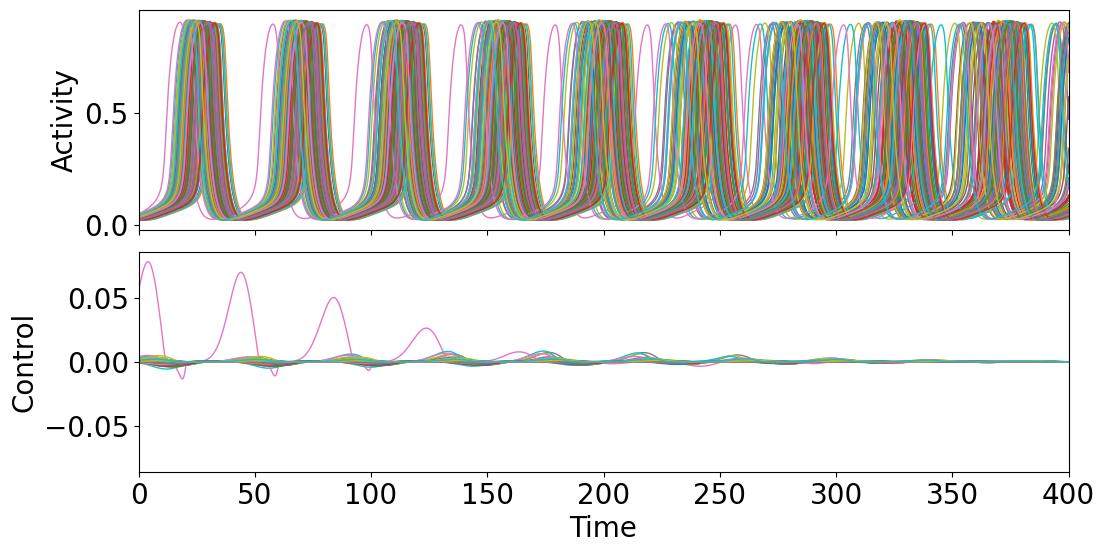

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.7267299097150353
Final cost : -0.7267299097150353
Compute control for a deterministic system
Cost in iteration 0: -0.7267299097150353
Cost in iteration 1: -0.7267367843284894
Cost in iteration 2: -0.7267499555707452
Cost in iteration 3: -0.7267779529305602
Cost in iteration 4: -0.7268138009217155
Final cost : -0.7268138009217155
Compute control for a deterministic system
Cost in iteration 0: -0.7268138009217155
Cost in iteration 1: -0.7268138252430285
Cost in iteration 2: -0.7268138716252601
Cost in iteration 3: -0.7268139558959397
Cost in iteration 4: -0.7268140944953642
Final cost : -0.7268140944953642
Compute control for a deterministic system
Cost in iteration 0: -0.7268140944953642
Cost in iteration 1: -0.7268192577131972
Cost in iteration 2: -0.7268192577131972
Cost in iteration 3: -0.726819257713197

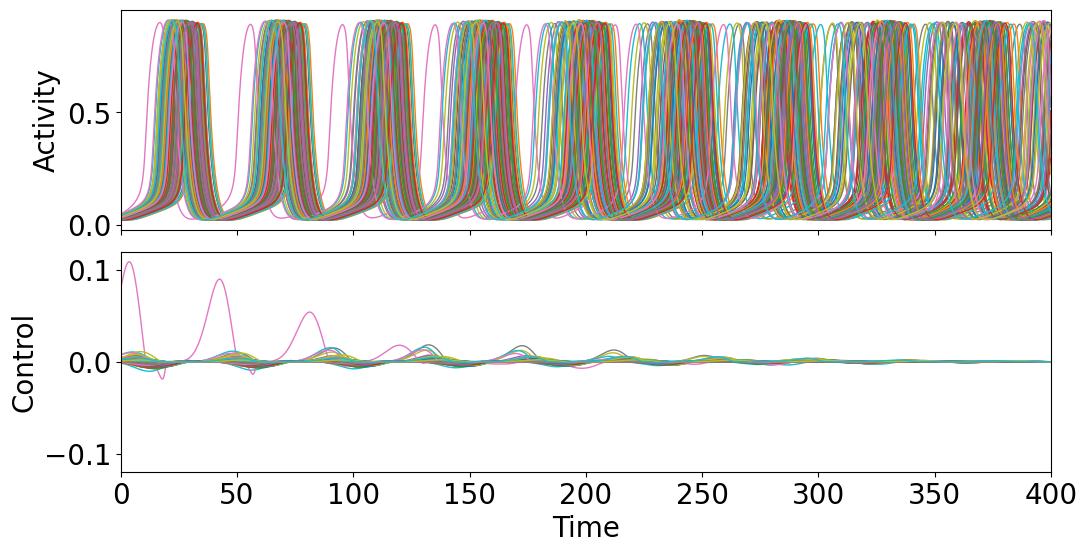

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -1.6762849224414136
Final cost : -1.6762849224414136
Compute control for a deterministic system
Cost in iteration 0: -1.6762849224414136
Cost in iteration 1: -1.6771295911018345
Cost in iteration 2: -1.678007381297617
Cost in iteration 3: -1.6796099020666597
Cost in iteration 4: -1.681697482896475
Final cost : -1.681697482896475
Compute control for a deterministic system
Cost in iteration 0: -1.681697482896475
Cost in iteration 1: -1.6817003150671486
Cost in iteration 2: -1.6817057412284258
Cost in iteration 3: -1.681715692336047
Cost in iteration 4: -1.6817323725462534
Final cost : -1.6817323725462534
Compute control for a deterministic system
Cost in iteration 0: -1.6817323725462534
Cost in iteration 1: -1.6862427031160105
Cost in iteration 2: -1.6869644651036035
Cost in iteration 3: -1.687035720298158
Cost

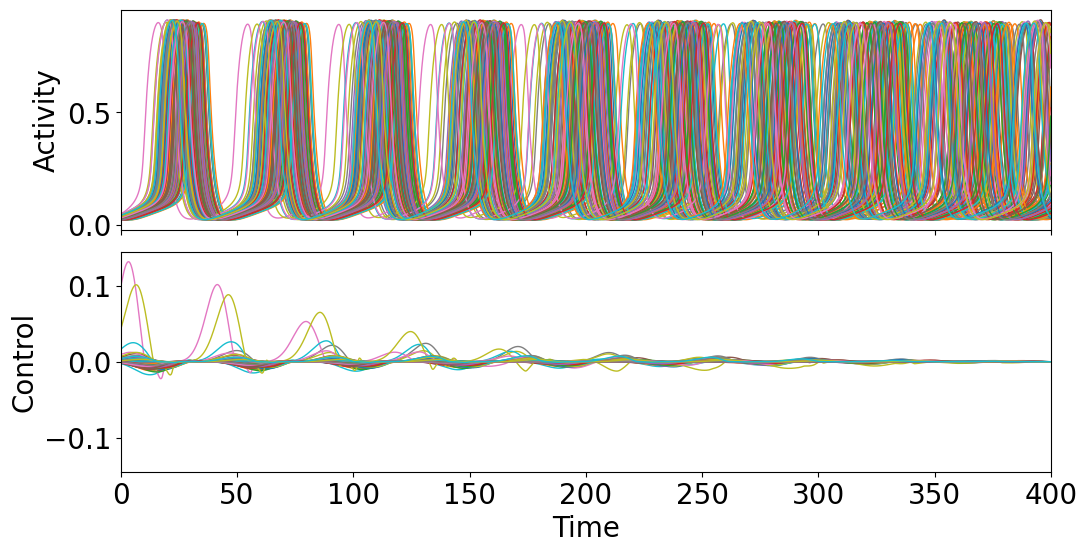

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 0.8429152999600632
Final cost : 0.8429152999600632
Compute control for a deterministic system
Cost in iteration 0: 0.8429152999600632
Cost in iteration 1: 0.8429152999600632
Converged in iteration 1 with cost 0.8429152999600632
Final cost : 0.8429152999600632
Compute control for a deterministic system
Cost in iteration 0: 0.8429152999600632
Cost in iteration 1: 0.842915299796635
Cost in iteration 2: 0.8429152997966276
Cost in iteration 3: 0.8429152997966274
Cost in iteration 4: 0.8429152997966273
Final cost : 0.8429152997966273
Compute control for a deterministic system
Cost in iteration 0: 0.8429152997966273
Cost in iteration 1: 0.8429152845195629
Cost in iteration 2: 0.8429152845195628
Cost in iteration 3: 0.8429152845195627
Cost in iteration 4: 0.8429152845195627
Final cost : 0.8429152845195627
Compute con

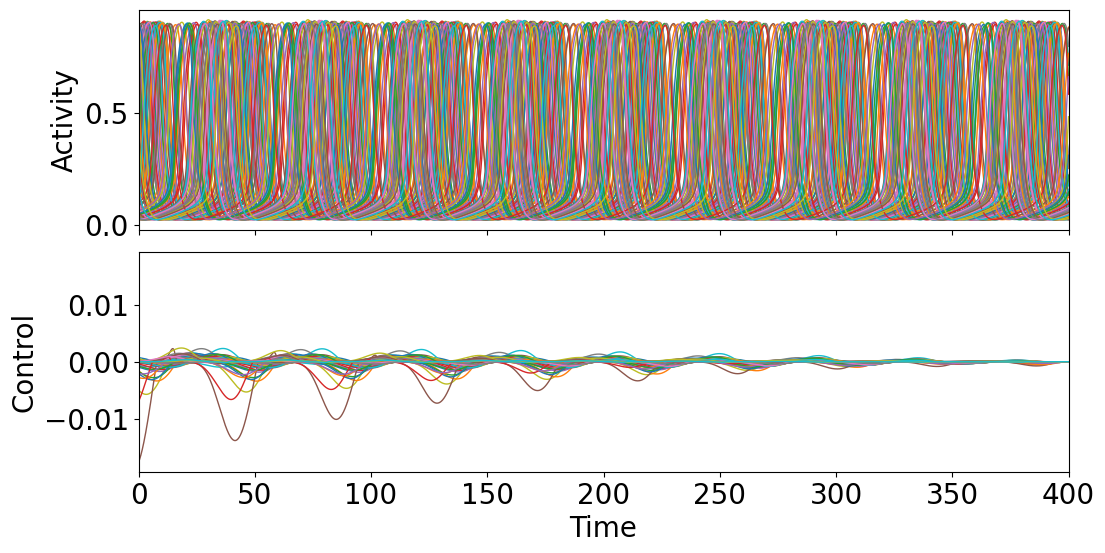

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 1.2467193413202526
Final cost : 1.2467193413202526
Compute control for a deterministic system
Cost in iteration 0: 1.2467193413202526
Cost in iteration 1: 1.2467193194403332
Cost in iteration 2: 1.2467192815606014
Cost in iteration 3: 1.2467192262661515
Cost in iteration 4: 1.2467191777439959
Final cost : 1.2467191777439959
Compute control for a deterministic system
Cost in iteration 0: 1.2467191777439959
Cost in iteration 1: 1.2467191742253128
Cost in iteration 2: 1.2467189923112376
Cost in iteration 3: 1.2467189189845842
Cost in iteration 4: 1.2467188815046963
Final cost : 1.2467188815046963
Compute control for a deterministic system
Cost in iteration 0: 1.2467188815046963
Cost in iteration 1: 1.2467188089534051
Cost in iteration 2: 1.2467187936075108
Cost in iteration 3: 1.2467187833103097
Cost in iteratio

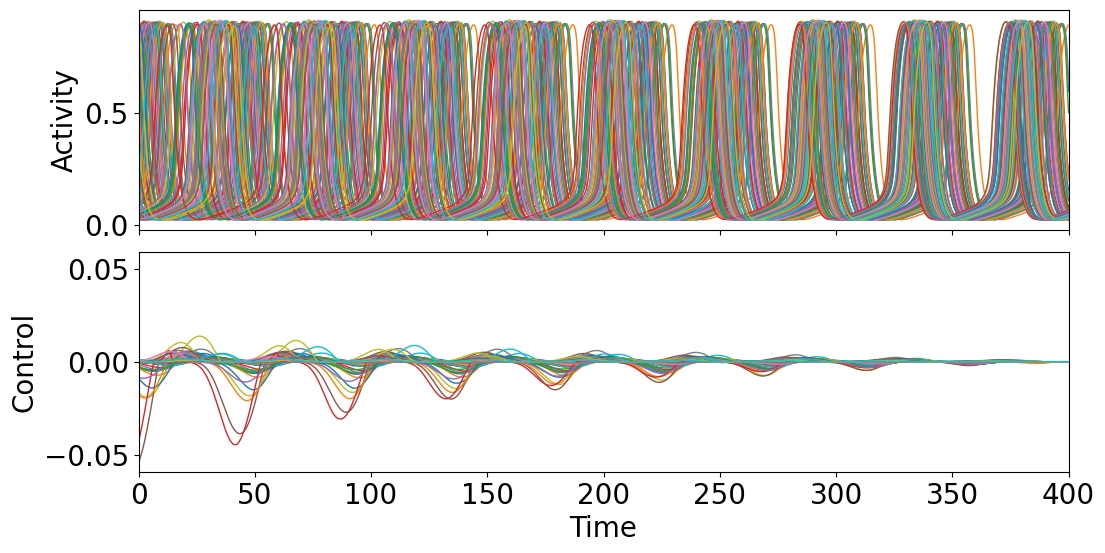

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 2.209839855716848
Final cost : 2.209839855716848
Compute control for a deterministic system
Cost in iteration 0: 2.209839855716848
Cost in iteration 1: 2.209818285159394
Cost in iteration 2: 2.209775184525011
Cost in iteration 3: 2.2096890962660725
Cost in iteration 4: 2.209516991684925
Final cost : 2.209516991684925
Compute control for a deterministic system
Cost in iteration 0: 2.209516991684925
Cost in iteration 1: 2.2095169856789534
Cost in iteration 2: 2.2095169746561436
Cost in iteration 3: 2.209516956203613
Cost in iteration 4: 2.209516931093011
Final cost : 2.209516931093011
Compute control for a deterministic system
Cost in iteration 0: 2.209516931093011
Cost in iteration 1: 2.2095169120560785
Cost in iteration 2: 2.209516912056077
Cost in iteration 3: 2.2095169120560763
Cost in iteration 4: 2.209516

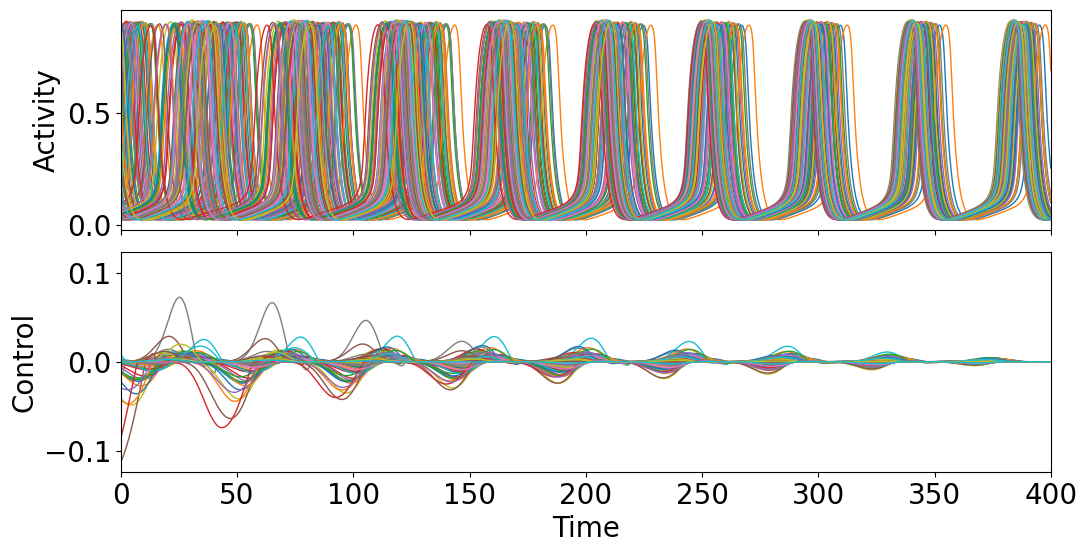

------------------------------------------------------------ wi =  0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.051335163294318885
Final cost : -0.051335163294318885
Compute control for a deterministic system
Cost in iteration 0: -0.051335163294318885
Cost in iteration 1: -0.05133516329431914
Cost in iteration 2: -0.0513351632943192
Cost in iteration 3: -0.051335163294319225
Cost in iteration 4: -0.051335163294319225
Final cost : -0.051335163294319225
Compute control for a deterministic system
Cost in iteration 0: -0.051335163294319225
Cost in iteration 1: -0.05133516338543989
Cost in iteration 2: -0.05133516338543989
Cost in iteration 3: -0.05133516338543989
Converged in iteration 3 with cost -0.05133516338543989
Final cost : -0.05133516338543989
Compute control for a deterministic system
Cost in iteration 0: -0.05133516338543989
Cost in iteration 1: -0.051335171911445106
Cost in iteration 2: -0.051335171950206725


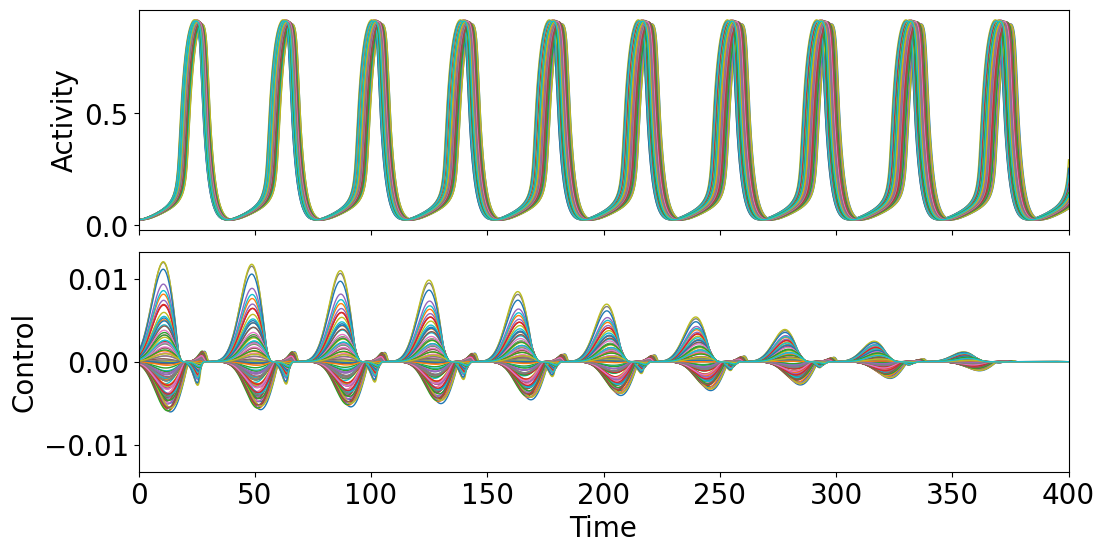

------------------------------------------------------------ wi =  1
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.2585805666192315
Final cost : -0.2585805666192315
Compute control for a deterministic system
Cost in iteration 0: -0.2585805666192315
Cost in iteration 1: -0.25902208754564743
Cost in iteration 2: -0.2593599093933814
Cost in iteration 3: -0.2597684019075544
Cost in iteration 4: -0.2605171672659746
Final cost : -0.2605171672659746
Compute control for a deterministic system
Cost in iteration 0: -0.2605171672659746
Cost in iteration 1: -0.2605172022658625
Cost in iteration 2: -0.2605172694638188
Cost in iteration 3: -0.2605173932233449
Cost in iteration 4: -0.2605176024593262
Final cost : -0.2605176024593262
Compute control for a deterministic system
Cost in iteration 0: -0.2605176024593262
Cost in iteration 1: -0.2605764078756615
Cost in iteration 2: -0.2605766632922377
Cost in iteration 3: -0.26059861698507

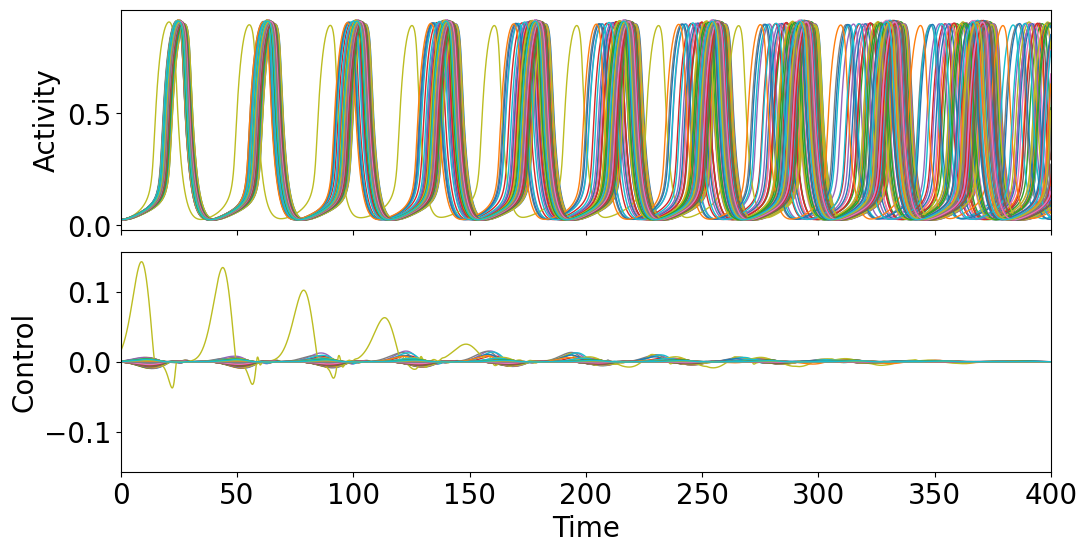

------------------------------------------------------------ wi =  2
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.8575927491451769
Final cost : -0.8575927491451769
Compute control for a deterministic system
Cost in iteration 0: -0.8575927491451769
Cost in iteration 1: -0.8584844591561227
Cost in iteration 2: -0.8592415227769313
Cost in iteration 3: -0.8606943008940882
Cost in iteration 4: -0.8619405576619752
Final cost : -0.8619405576619752
Compute control for a deterministic system
Cost in iteration 0: -0.8619405576619752
Cost in iteration 1: -0.8619406331918877
Cost in iteration 2: -0.8619407774955473
Cost in iteration 3: -0.8627653450615937
Cost in iteration 4: -0.8631109590965942
Final cost : -0.8631109590965942
Compute control for a deterministic system
Cost in iteration 0: -0.8631109590965942
Cost in iteration 1: -0.8635075425222194
Cost in iteration 2: -0.8704662489844406
Cost in iteration 3: -0.870832900041115

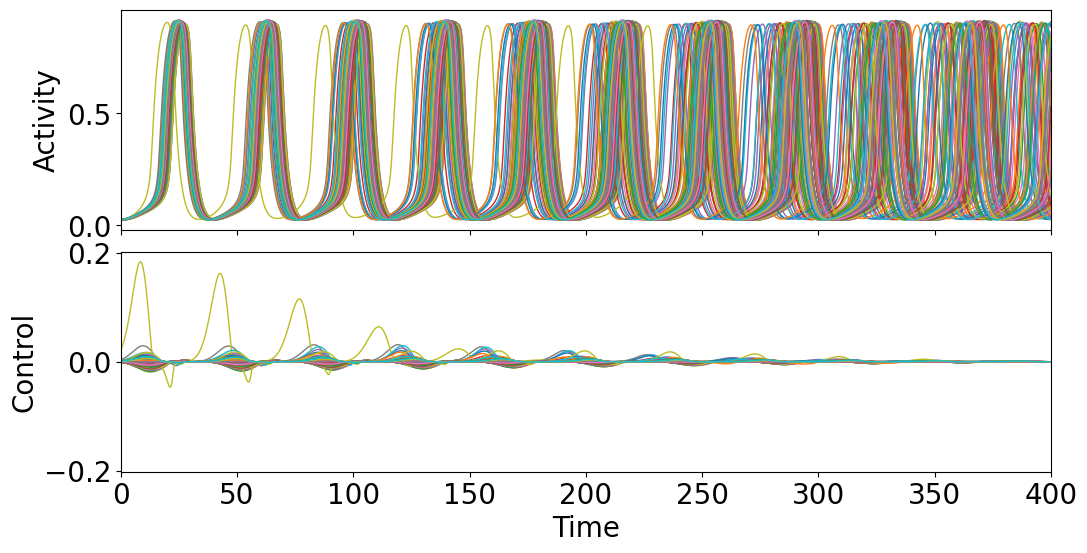

In [12]:
it = 4

for d in [data_0, data_1, data_2]:

    for wi in range(3):
        print("------------------------------------------------------------ wi = ", wi)

        #if wi not in [2]: continue

        model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
        model.params.exc_init = d["init_state"][0]
        model.params.inh_init = d["init_state"][1]
        setparams(model)

        model.params["exc_ext_baseline"] =  d["coordinates"][0]
        model.params["inh_ext_baseline"] =  d["coordinates"][1]
        model.params.duration = duration
        dt = model.params.dt

        model.run()

        model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
        model_controlled.weights["w_p"] = 0.
        model_controlled.weights["w_2"] = 1.
        model_controlled.weights["w_var"] = d["weights"][wi]

        model_controlled.maximum_control_strength = max_cntrl

        model_controlled.control = d["control"][wi].copy()
        model_controlled.update_input()
        model_controlled.simulate_forward()
        model_controlled.optimize(0)

        for j in range(2):
            for gm in [0]:
                model_controlled.grad_method = gm

                model_controlled.channelwise_optimization = False

                for k in range(-2, 4, 2):
                    model_controlled.zero_step_encountered = False
                    model_controlled.step = 10.**(k)
                    model_controlled.optimize(it)

                    get_results(d, wi, model_controlled)
                    dump_data()

                    model_controlled.channelwise_optimization = True

                    for k in range(-2, 4, 2):
                        model_controlled.zero_step_encountered = False
                        model_controlled.step = 10.**(k)
                        model_controlled.optimize(it)

                        get_results(d, wi, model_controlled)
                        dump_data()

        plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

------------------------------------------------------------ wi =  0


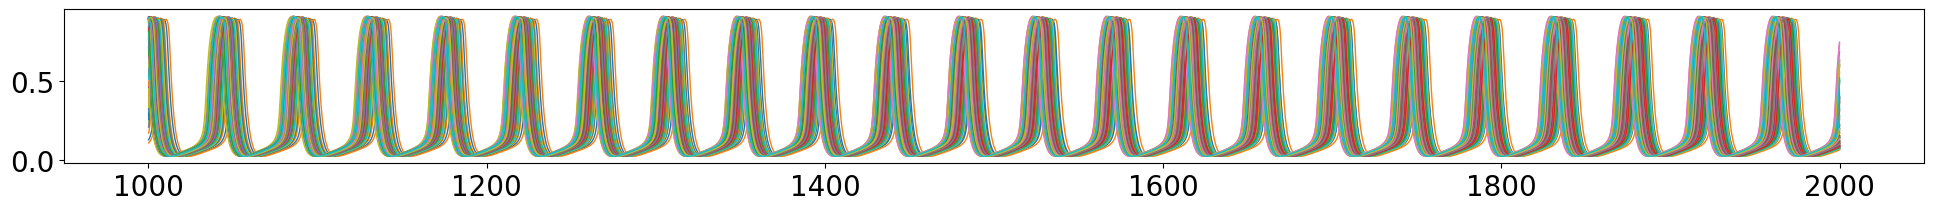

------------------------------------------------------------ wi =  1


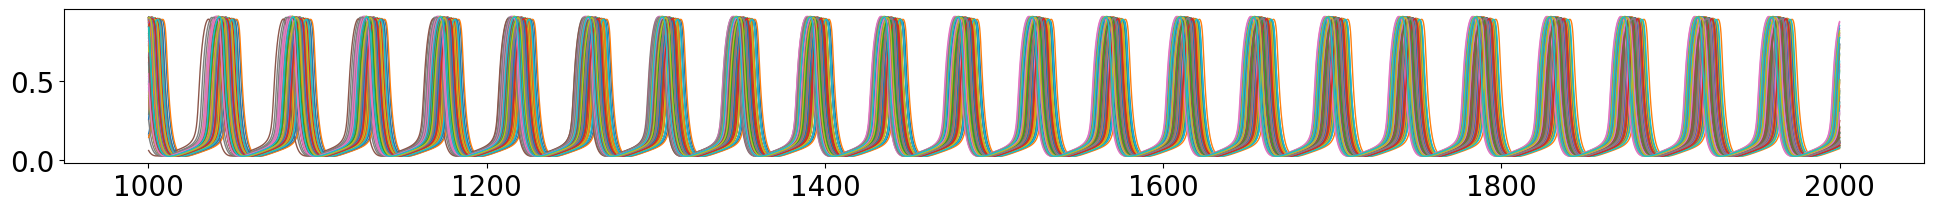

------------------------------------------------------------ wi =  2


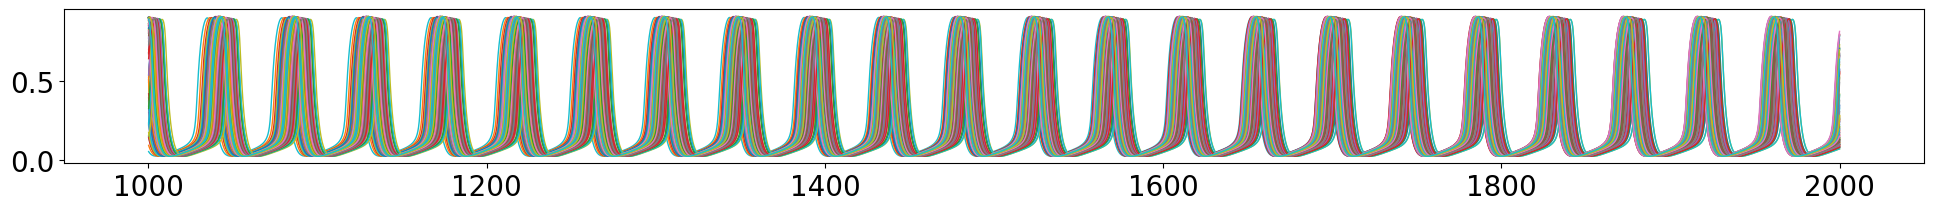

In [15]:
d = data_1


for wi in range(3):
    print("------------------------------------------------------------ wi = ", wi)

    #if wi in [1,2]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = 2. * 1e3
    dt = model.params.dt

    cntrl = np.zeros((N, 2, int(model.params.duration/dt)+1))
    cntrl[:,:,:4001] = d["control"][wi]

    model.params.exc_ext = cntrl[:,0,:]

    model.run()

    plt.figure(figsize=(24,2))
    for n in range(N):
        plt.plot(model.t[-10000:], model.exc[n,-10000:])
        
    plt.show()


# task 1: 

###################### control task 1